# Lab 05：把 OpenAI 的 GPT-2 裝進自己寫的模型

對應講義：[第 05 課](../lessons/05_gpt2.md)

1. 下載 GPT-2 124M 的權重（548 MB），用本課程的 `GPT` 類別載入，對照參考 logits
2. 解碼策略：greedy、temperature、top-k、top-p（式 5.3–5.5）
3. GPT-2 在 TinyStories 上的 bits-per-byte（Lab 06 會回來比較）
4. 初始化實驗：residual 投影不縮小會怎樣（式 5.2）
5. GPT-2 的 token embedding 裡也有「詞向量」

CPU 約 1 分鐘（不含第一次下載）。模型生成的文字依 GPT-2 的授權（Modified MIT）標示：**以下範例文字由 GPT-2 生成**。

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
torch.set_grad_enabled(False)
print(f"torch {torch.__version__}")

torch 2.14.0+cu130


## 1. 載入權重

In [2]:
from lm_course.model import load_gpt2_pretrained, parameter_summary
from lm_course.tokenizer import gpt2_tokenizer

start = time.perf_counter()
model = load_gpt2_pretrained().eval()
tok = gpt2_tokenizer()
print(f"loaded in {time.perf_counter() - start:.0f}s")
summary = parameter_summary(model)
print(f"total {summary.total:,} parameters, {summary.non_embedding:,} without embeddings")
for group, n in summary.by_group.items():
    print(f"  {group:<20} {n:>12,}")

loaded in 4s
total 124,439,808 parameters, 85,056,000 without embeddings
  token_embedding        38,597,376
  position_embedding        786,432
  norm1                      18,432
  attn                   28,348,416
  norm2                      18,432
  mlp                    56,669,184
  final_norm                  1,536


對照參考值：以下兩組數字是用 Hugging Face transformers 的 `GPT2LMHeadModel` 算的（2026-09-25，課程撰寫時）。
我們的實作必須給出相同的前 5 名 token，最大 logit 也要吻合到小數點後兩位。

In [3]:
reference = {
    "The capital of France is": ([262, 783, 257, 4881, 6342], -100.25),
    "Hello, my name is": ([1757, 509, 449, 3899, 406], -64.443),
}
for prompt, (top5, top_logit) in reference.items():
    logits = model(torch.tensor([tok.encode(prompt)]))[0, -1]
    ours = torch.topk(logits, 5)
    print(f"{prompt!r}")
    print(f"   ours      {ours.indices.tolist()}  max logit {ours.values[0]:.3f}  -> {[tok.decode([i]) for i in ours.indices.tolist()]}")
    print(f"   reference {top5}  max logit {top_logit:.3f}")

'The capital of France is'
   ours      [262, 783, 257, 4881, 6342]  max logit -100.250  -> [' the', ' now', ' a', ' France', ' Paris']
   reference [262, 783, 257, 4881, 6342]  max logit -100.250
'Hello, my name is'
   ours      [1757, 509, 449, 3899, 406]  max logit -64.443  -> [' John', ' K', ' J', ' Michael', ' L']
   reference [1757, 509, 449, 3899, 406]  max logit -64.443


logit 是負的一百多，看起來很怪，但只有差值有意義（softmax 對所有 logit 加同一個常數不變）。
「The capital of France is」的第一名是「 the」、第五名才是「 Paris」——124M 的小模型知道答案相關，但更習慣先接一個冠詞。

## 2. 解碼策略

In [4]:
from lm_course.sampling import generate, next_token_probs

prompt = "In a small village by the sea, there lived an old fisherman who"
ids = tok.encode(prompt)
settings = {
    "greedy": dict(temperature=0.0),
    "temperature 1.0": dict(temperature=1.0),
    "temperature 0.7, top-k 50": dict(temperature=0.7, top_k=50),
    "top-p 0.9": dict(temperature=1.0, top_p=0.9),
}
for name, kwargs in settings.items():
    out = generate(model, ids, 60, generator=torch.Generator().manual_seed(1), **kwargs)[0]
    print(f"--- {name} ---")
    print(prompt + tok.decode(out))
    print()

--- greedy ---
In a small village by the sea, there lived an old fisherman who had been a fisherman for many years. He had been a fisherman for many years, and he had been a fisherman for many years. He had been a fisherman for many years, and he had been a fisherman for many years. He had been a fisherman for many years, and he had been a



--- temperature 1.0 ---
In a small village by the sea, there lived an old fisherman who was proficient in the news gathering. Renadd would carry him aboard the ship and, as it arrived at sea, lead him to small villages of fishermen, students, and merchants and trained them for Tidus. Other travelers would visit the merchant, as well, and would eventually reach war goals between the



--- temperature 0.7, top-k 50 ---
In a small village by the sea, there lived an old fisherman who was a hard worker. He took the old fisherman's fish, but then he began to die. He was the son of the old fisherman, who had been a fisherman in the night and had died. A very old fisherman, the son of a fisherman, died.

The old fisherman's



--- top-p 0.9 ---
In a small village by the sea, there lived an old fisherman who was proficient in the news gathering.


When he saw Sinomedea and Erendia in his sea-dwelling state, he darted forward to avoid going and trained them for a month. Meanwhile, Enidia and Qithona led the sheep into the forest and they were blinded



greedy 很快就開始重複同一句話（講義 §2.6 的 degeneration）；temperature 1.0 的純抽樣會跑出很怪的字與名字；截斷後（top-k／top-p）通常在「通順」與「多樣」之間取得平衡——但只是降低機率，不是保證：這次 top-p 0.9 仍然跑出了怪名字（它和純抽樣用同一個種子，開頭幾個字也一樣）。

**top-k 與 top-p 在不同形狀的分布上**：一個前文讓下一個字很確定、另一個前文很開放，各自保留幾個候選？

In [5]:
contexts = {
    "peaked": "The United States of",
    "flat": "My favorite thing is",
}
for name, text in contexts.items():
    logits = model(torch.tensor([tok.encode(text)]))[0, -1]
    probs = next_token_probs(logits[None])[0]
    top = torch.topk(probs, 5)
    kept_p = (next_token_probs(logits[None], top_p=0.9)[0] > 0).sum().item()
    print(f"{name:>6} {text!r}: top-5 {[(tok.decode([int(i)]), round(p.item(), 3)) for p, i in zip(top.values, top.indices)]}")
    print(f"        top-p 0.9 keeps {kept_p} tokens; top-k 50 always keeps 50")

peaked 'The United States of': top-5 [(' America', 0.966), (' the', 0.003), (' Europe', 0.003), (' A', 0.001), (' American', 0.001)]
        top-p 0.9 keeps 1 tokens; top-k 50 always keeps 50
  flat 'My favorite thing is': top-5 [(' that', 0.242), (' the', 0.099), (' to', 0.094), (' when', 0.081), (' how', 0.044)]
        top-p 0.9 keeps 202 tokens; top-k 50 always keeps 50


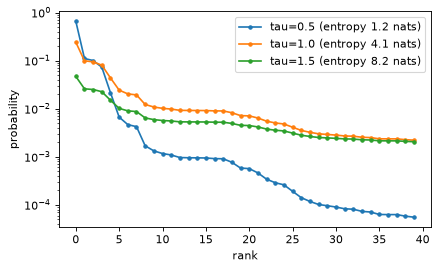

In [6]:
logits = model(torch.tensor([tok.encode("My favorite thing is")]))[0, -1]
plt.figure(figsize=(6, 3.5))
for tau in (0.5, 1.0, 1.5):
    probs = torch.softmax(logits / tau, dim=-1)
    entropy = -(probs * probs.clamp_min(1e-12).log()).sum().item()
    plt.plot(torch.sort(probs, descending=True).values[:40].numpy(), "o-", ms=3, label=f"tau={tau} (entropy {entropy:.1f} nats)")
plt.yscale("log")
plt.xlabel("rank")
plt.ylabel("probability")
plt.legend()
plt.show()

## 3. GPT-2 在 TinyStories 上

bits-per-byte 與 tokenizer 無關（講義第 01 課式 1.4），所以可以拿 GPT-2（50,257 個 token）和 Lab 06 的小模型（4,096 個 token）直接比較。
取驗證故事的前 32 個 1024-token 視窗。

In [7]:
from lm_course.artifacts import course_stories
from lm_course.training import evaluate

_, val_stories = course_stories()
eot = tok.special_id("<|endoftext|>")
ids = []
for story in val_stories:
    ids += [eot] + tok.encode(story)
val_tokens = np.array(ids, dtype=np.int32)
token_bytes = torch.tensor(tok.token_byte_lengths())
start = time.perf_counter()
result = evaluate(model, val_tokens, context_length=1024, batch_size=8, max_batches=4, token_bytes=token_bytes)
print(f"GPT-2 124M on TinyStories validation: {result.loss:.3f} nats/token, {result.bits_per_byte:.3f} bits/byte ({time.perf_counter() - start:.0f}s)")
print(f"bytes per GPT-2 token here: {sum(len(s.encode()) for s in val_stories) / len(val_tokens):.2f}")

GPT-2 124M on TinyStories validation: 2.440 nats/token, 0.872 bits/byte (33s)
bytes per GPT-2 token here: 4.03


GPT-2 沒看過 TinyStories，但幼兒故事對它來說很好預測。記下這個 bits-per-byte：Lab 06 只有 500 萬參數、在 TinyStories 上訓練約半小時的模型，會和它比一比。

## 4. 初始化：residual stream 隨深度長大

隨機初始化一個 12 層、$d = 256$ 的 GPT-2 形狀模型，量每一層之後 residual stream 的標準差。比較「照 GPT-2 縮小 $W_O$、$W_2$」與「所有權重都用 0.02」。

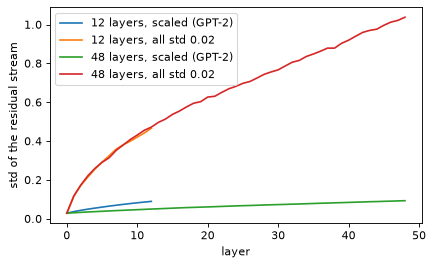

In [8]:
from lm_course.model import GPT, gpt2_config


def residual_std_by_layer(model: GPT, idx: torch.Tensor) -> list[float]:
    stds = []
    x = model.token_embedding(idx) + model.position_embedding(torch.arange(idx.shape[1]))
    stds.append(x.std().item())
    for layer, block in enumerate(model.blocks):
        x = block(x, None, layer, None)
        stds.append(x.std().item())
    return stds


idx = torch.randint(0, 4096, (8, 128))
plt.figure(figsize=(6, 3.5))
for n_layer in (12, 48):
    cfg = gpt2_config("gpt2", vocab_size=4096, context_length=128, n_layer=n_layer, n_head=4, d_model=256)
    scaled = GPT(cfg)
    unscaled = GPT(cfg)
    for name, p in unscaled.named_parameters():
        if name.endswith(("out_proj.weight", "down_proj.weight")):
            torch.nn.init.normal_(p, std=0.02)
    for m, label in [(scaled, "scaled (GPT-2)"), (unscaled, "all std 0.02")]:
        plt.plot(residual_std_by_layer(m, idx), label=f"{n_layer} layers, {label}")
plt.xlabel("layer")
plt.ylabel("std of the residual stream")
plt.legend()
plt.show()

不縮放時，residual stream 的標準差隨層數一路長大（越深越明顯）；照式 (5.2) 縮放後，幾乎和深度無關。

## 5. GPT-2 的 embedding 裡也有詞向量

GPT-2 的 token embedding 表（同時也是輸出層，weight tying）。它和第 02 課的 word2vec 是同一種東西嗎？看幾個 token 的最近鄰居（餘弦相似度）。

In [9]:
E = model.token_embedding.weight
unit = E / E.norm(dim=1, keepdim=True)

def neighbours(word: str, k: int = 8) -> list[str]:
    (i,) = tok.encode(word)
    sims = unit @ unit[i]
    top = torch.topk(sims, k + 1).indices.tolist()
    return [tok.decode([j]) for j in top if j != i][:k]

for word in [" king", " dog", " happy", " Paris", " seven", " running"]:
    print(f"{word!r:>11} -> {neighbours(word)}")

def analogy(a: str, b: str, c: str) -> str:
    ia, ib, ic = (tok.encode(w)[0] for w in (a, b, c))
    target = unit[ib] - unit[ia] + unit[ic]
    sims = unit @ (target / target.norm())
    sims[[ia, ib, ic]] = -1
    return tok.decode([int(sims.argmax())])

print()
for a, b, c in [(" man", " woman", " king"), (" France", " Paris", " Japan"), (" walk", " walked", " run")]:
    print(f"{a} : {b} :: {c} : {analogy(a, b, c)!r}")

    ' king' -> [' kings', ' King', ' queen', 'King', ' prince', ' monarch', ' emperor', ' ruler']
     ' dog' -> [' dogs', ' Dog', 'Dog', ' canine', 'dog', ' Dogs', ' puppy', ' pet']
   ' happy' -> ['happy', ' Happy', ' happier', ' unhappy', 'Happy', ' pleased', ' glad', ' thrilled']
   ' Paris' -> ['Paris', ' France', ' French', ' London', 'France', ' Copenhagen', ' Brussels', 'French']
   ' seven' -> [' six', ' eight', ' five', ' nine', ' four', ' three', 'seven', 'Seven']
 ' running' -> [' Running', 'Running', 'running', ' ran', ' run', ' runs', ' Run', 'Run']

 man :  woman ::  king : ' queen'
 France :  Paris ::  Japan : ' Tokyo'
 walk :  walked ::  run : ' ran'


鄰居大多是同一類的詞，也常出現大小寫或有無空白的「同一個字的變體」（BPE 的副作用）。這三個類比都答對了。
差別是：word2vec 的向量只為了猜鄰居而學；GPT-2 的 embedding 是整個模型的一部分，真正「依上下文」的意思在後面的層裡才形成（第 13 課會用那些層做句子 embedding）。

## 小結

- 本課程的 `GPT` 載入 OpenAI 權重後，輸出與參考實作一致：架構（式 5.1）、tokenizer（Lab 03）都對了。
- 解碼策略決定了文字的樣子：greedy 重複、純抽樣離題、top-k／top-p 折衷。
- residual 投影的縮放讓深層網路在初始化時保持穩定。

下一步：[第 06 課](../lessons/06_pretraining.md)——自己訓練一個。